# Example for interactions with the array backends.

This example demonstrates how to use the pyRadPlan library to use and interact
with the underlying array api backends. These are povided by the 'xp_utils' module.

If you find bugs or that your desired backend is not working properly,
feel free to open an issue and reach out to us on github.
Improvements are also very welcome :)

To display this script in a Jupyter Notebook, you need to install jupytext via pip and run the following command.
This will create a .ipynb file in the same directory:

```bash
pip install jupytext
jupytext --to notebook path/to/this/file/utils_backends.py
```

In [1]:
# Import necessary libraries
import logging

import numpy as np

from pyRadPlan import (
    IonPlan,
    generate_stf,
    calc_dose_influence,
    fluence_optimization,
    plot_slice,
    load_tg119,
    settings,
    xp_utils,
)

from pyRadPlan.gui import launch_viewer, GUI_AVAILABLE
from pyRadPlan.optimization.objectives import SquaredDeviation, SquaredOverdosing, MeanDose

C:\NiklasLocal\python\pyRadPlan\.venv313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Exploring and Setting Backends
The pyRadPlan Array API backend (`xp_utils`) allows using multiple computational
backends seamlessly.
Natively, every library which complies to the array API standard should be supported.
In pyRadPlan however, we recommend using either NumPy (out of the box) or CuPy / PyTorch (GPU) for low grid sizes, especially for electrons.

On the main webpage for cupy and pytorch you can find instructions on how to install it for your system.

The following lines of code check your system for available backends.

In [2]:
print("--- Available Computational Backends ---")
print("NumPy available: True (Default CPU)")
print(
    f"PyTorch available: {xp_utils.pytorch_available()} (GPU: {xp_utils.pytorch_gpu_available()})"
)
print(f"CuPy available: {xp_utils.cupy_available()}")
print(f"JAX available: {xp_utils.jax_available()} (GPU: {xp_utils.jax_gpu_available()})")

# The preferred backends are the "xp" sub-configuration of the global pyRadPlan
# settings. They can be configured via environment variables / a `.env` file
# (PYRADPLAN_XP_PREFER_GPU, PYRADPLAN_XP_PREFERRED_CPU_ARRAY_BACKEND,
# PYRADPLAN_XP_PREFERRED_GPU_ARRAY_BACKEND) or at runtime as below.

# Let's start by calculating the dose influence matrix (dij) on the CPU
print("\nConfiguring CPU Backend (NumPy) for Dose Calculation...")
settings.xp.prefer_gpu = False
settings.xp.preferred_cpu_array_backend = "numpy"
logging.basicConfig(level=logging.INFO)

--- Available Computational Backends ---
NumPy available: True (Default CPU)
PyTorch available: False (GPU: False)
CuPy available: False
JAX available: False (GPU: False)

Configuring CPU Backend (NumPy) for Dose Calculation...


In [3]:
# Load TG119 (provided within pyRadPlan)
ct, cst = load_tg119()

In this section, we create a proton therapy plan using the ParticleHongPencilBeamEngine.

In [4]:
# Create a plan object
pln = IonPlan(radiation_mode="protons", machine="Generic")
pln.prop_opt = {"solver": "scipy"}
pln.prop_dose_calc = {"dose_grid": {"resolution": (2.0, 2.0, 2.0)}}

# Generate Steering Geometry ("stf")
stf = generate_stf(ct, cst, pln)

# Calculate Dose Influence Matrix ("dij")
dij = calc_dose_influence(ct, cst, stf, pln)

# Optimization
cst.vois[0].objectives = [SquaredOverdosing(priority=10.0, d_max=1.0)]  # OAR
cst.vois[1].objectives = [SquaredDeviation(priority=100.0, d_ref=3.0)]  # Target
cst.vois[2].objectives = [
    MeanDose(priority=1.0, d_ref=0.0),
    SquaredOverdosing(priority=10.0, d_max=2.0),
]  # BODY

Beam:   0%|          | 0/1 [00:00<?, ?b/s]

C:\NiklasLocal\python\pyRadPlan\pyRadPlan\raytracer\_siddon.py:359: RuntimeWarning: divide by zero encountered in divide
  (p_min - self._source_points) / self._ray_vec,  # alpha to "near" plane
C:\NiklasLocal\python\pyRadPlan\pyRadPlan\raytracer\_siddon.py:360: RuntimeWarning: divide by zero encountered in divide
  (p_max - self._source_points) / self._ray_vec,


Beam: 100%|██████████| 1/1 [00:00<00:00,  3.46b/s]

INFO:pyRadPlan.dose.engines._base:Dose influence matrix calculation using 'Hong Particle Pencil-Beam' Dose Engine...


INFO:pyRadPlan.dose.engines._base:Dose Grid has Dimensions (251,251,162) with resolution x=2.000000, y=2.000000, z=2.000000.


...

Ray:  99%|█████████▉| 314/316 [00:07<00:00, 38.04r/s]

Beam: 100%|██████████| 1/1 [00:08<00:00,  8.94s/b]

INFO:pyRadPlan.dose.engines._base_pencilbeam:Finalizing dose calculation...


INFO:pyRadPlan.dose.engines._base_pencilbeam:Done in 0.005615 seconds.


INFO:pyRadPlan.dose.engines._base:Dose influence matrix calculation done in 9.93 seconds.


## 2. Changing the Backend before Optimization
If you wanted to switch to a GPU backend mid-code you can do so.

Here we switch the backends before optimization:

In [5]:
print("\n--- Switching to a GPU Backend for Optimization ---")
settings.xp.prefer_gpu = True

# `preferred_gpu_array_backend = None` selects the best available GPU backend automatically
print(f"Accelerated GPU backend selected: {xp_utils.choose_array_api_namespace().__name__}")

# or you can force a specific backend:
# settings.xp.preferred_gpu_array_backend = "torch"  # or "cupy"

# Calculate optimized fluence
fluence = fluence_optimization(ct, cst, stf, dij, pln)

# Compute the result on the CT grid
result = dij.compute_result_ct_grid(fluence)


--- Switching to a GPU Backend for Optimization ---
Accelerated GPU backend selected: array_api_compat.numpy


INFO:pyRadPlan.optimization.problems._optiprob:Converting all objectives to use quantity: physical_dose


INFO:pyRadPlan.dij._dij:Converted Dij to namespace 'array_api_compat.numpy'


INFO:pyRadPlan.quantities._base:Optimization will use array backend: array_api_compat.numpy


INFO:pyRadPlan.util.keyboard_listener:Press 'q' or ESC to stop optimization early.


INFO:pyRadPlan.optimization.solvers._base_solvers:Starting optimization using SciPy minimize


INFO:pyRadPlan.util.keyboard_listener:Optimization aborted by user. Returning last known iterate.


INFO:pyRadPlan.optimization.problems._nonlin_fluence:166 Objective function evaluations, avg. time: 0.0754187 +/- 0.00675574 s


INFO:pyRadPlan.optimization.problems._nonlin_fluence:166 Derivative evaluations, avg. time: 0.124848 +/- 0.00837325 s


INFO:pyRadPlan.optimization.problems._nonlin_fluence:Solver time: 33.4197 s


Visualize the results

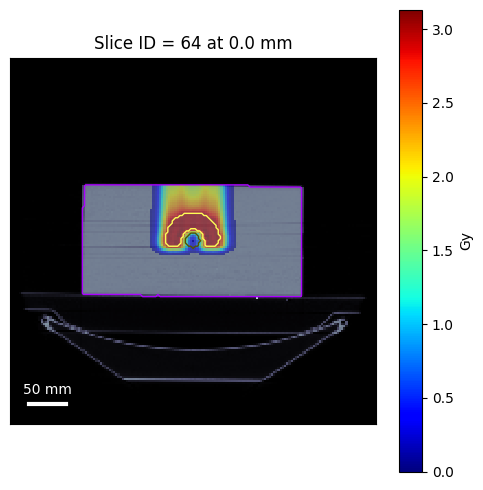

In [6]:
if GUI_AVAILABLE:
    # Use the GUI if [gui] dependencies are installed
    launch_viewer(ct, cst, result)
else:
    # Choose a slice to visualize
    view_slice = int(np.round(ct.size[2] / 2))

    # Visualize
    plot_slice(
        image_volume=ct,
        cst=cst,
        overlay=result["physical_dose"],
        view_slice=view_slice,
        plane="axial",
        overlay_unit="Gy",
    )